In [1]:
# imports
import numpy as np
import torch
from er_evaluation import pairwise_f, pairwise_precision, pairwise_recall
from torch.utils.data import DataLoader, ConcatDataset, random_split, TensorDataset
from dataset_utils.Cresci17 import Cresci17, Cresci17SetTypes
from transformers import DistilBertTokenizer, AutoModel
import math
import re
import hdbscan
import matplotlib.pyplot as plt
import umap
from sklearn.metrics import confusion_matrix, adjusted_rand_score, normalized_mutual_info_score, accuracy_score, \
    f1_score, recall_score
from sklearn.preprocessing import RobustScaler
from hdbscan import approximate_predict
import joblib
from torch import nn
from pipeline_utils import create_profile_vector, create_tweet_vectors, train_classifier, test_classifier
from ClassificationHeads import BaselineClassificationHead

c:\Users\Hamouda\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load dataset
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# use generator to get consistent dataset split between re-runs
generator = torch.Generator().manual_seed(42)
social_spam1_train, social_spam1_test = random_split(Cresci17(root="./datasets", subset_type=Cresci17SetTypes.SOCIAL_SPAM_1),[0.8,0.2], generator=generator)
fake_follower_train, fake_follower_test = random_split(Cresci17(root="./datasets", subset_type=Cresci17SetTypes.FAKE_FOLLOWER),[0.8,0.2], generator=generator)
genuine_user_train, genuine_user_test = random_split(Cresci17(root="./datasets", subset_type=Cresci17SetTypes.GENUINE_USER),[0.8,0.2], generator=generator)
traditional_spam = Cresci17(root="./datasets", subset_type=Cresci17SetTypes.TRADITIONAL_SPAM_1)

train_dataloader = DataLoader(ConcatDataset([social_spam1_train,genuine_user_train,fake_follower_train]), batch_size=None, batch_sampler=None, shuffle=True, pin_memory=True)
test_dataloader = DataLoader(ConcatDataset([social_spam1_test,genuine_user_test,fake_follower_test]), batch_size=None, batch_sampler=None, shuffle=True, pin_memory=True)

d:\Ulm\NLP AND NLM\Project\-Social-Media-Bot-Detection-with-Continuous-Learning\dataset_utils\Cresci17.py:80: DtypeWarning: Columns (0: favorite_count) have mixed types. Specify dtype option on import or set low_memory=False.
  self.tweet_data = pd.read_csv(tweet_data_path, encoding="latin-1", dtype={'id': str},


In [3]:


# initiate models
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased").to(device)
dim_reducer = umap.UMAP(n_components=15, n_neighbors=20, min_dist=0.1, metric="cosine")
clusterer = hdbscan.HDBSCAN(min_cluster_size=60, min_samples=20, prediction_data=True, cluster_selection_epsilon=0.5)
scaler = RobustScaler(with_centering=False)
classifier = BaselineClassificationHead(23,10).to(device)

# training loop
ground_truth_labels = []
profile_vectors = []
tweet_vectors = []
for i, batch in enumerate(train_dataloader):
    data, label = batch
    # get feature vectors
    profile_embed = create_profile_vector(data)
    tweet_embeds = create_tweet_vectors(data, tokenizer, model, max_tweets= 50, batch_size = 50)

    # pool tweet vectors
    tweet_vec = torch.mean(tweet_embeds, dim=0, dtype=torch.float32)

    # append feature vectors and ground truth
    profile_vectors.append(profile_embed)
    tweet_vectors.append(tweet_vec)
    ground_truth_labels.append(label)
    print(i)

# reduce tweet vectors in dimensionality
reduced_tweet_vectors = dim_reducer.fit_transform(tweet_vectors)
reduced_tweet_vectors = np.nan_to_num(reduced_tweet_vectors, nan=0.0, posinf=0.0, neginf=0.0)

# scale profile vectors
scaled_profile_vectors = scaler.fit_transform(profile_vectors)

# combine feature vectors
embedding_features = [np.concatenate((t1, t2), axis=0) for t1, t2 in zip(reduced_tweet_vectors, scaled_profile_vectors)]

# perform clustering
cluster_labels = clusterer.fit_predict(embedding_features)

# perform classification training

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=0.01)

ground_truths, predictions = train_classifier(classifier, criterion, optimizer, embedding_features, ground_truth_labels)

print("accuracy: ", accuracy_score(ground_truths, predictions))
print("recall: ", recall_score(ground_truths, predictions, average="macro"))
print("f1 score: ", f1_score(ground_truths, predictions, average="macro"))
print(confusion_matrix(ground_truths, predictions))

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8333.77it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

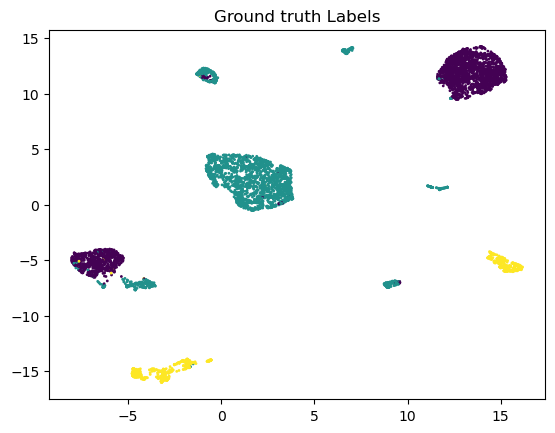

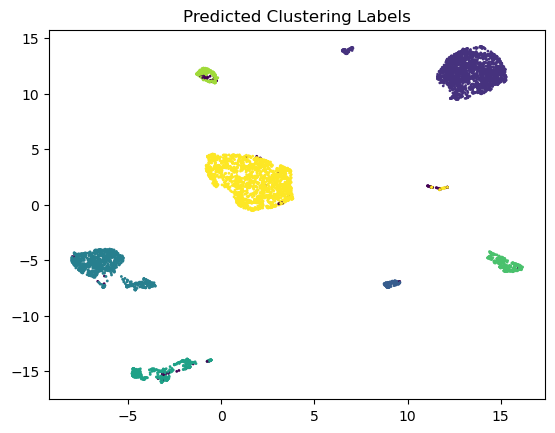

6253
Predicted Labels:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(-1)]
[[   0    0    0    0    0    0    0    0]
 [1918   11  802    0    0    1    1   46]
 [ 120  118  253    1    0  198 1942   49]
 [   0    0    8  454  312    0    0   19]
 [   0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0]]
Precision:  0.9046347895017365
Recall:  0.5489598471609002
F1 score 0.6832828950462944
Adjusted Rand Index:  0.5474757582756251
Normalized Mutual Info:  0.5986364187553205


In [4]:
# evaluation

# remap feature vectors to 2D representation for plotting
plot_reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1)
coords = plot_reducer.fit_transform(embedding_features)
# plot ground truth
plt.title("Ground truth Labels")
plt.scatter(coords[:, 0], coords[:, 1], s=1, c=ground_truth_labels)
plt.show()
# plot predictions labels
plt.title("Predicted Clustering Labels")
plt.scatter(coords[:, 0], coords[:, 1], s=1, c=cluster_labels)
plt.show()

# calculate metrics
print(len(ground_truth_labels))
print("Predicted Labels: ", list(set(cluster_labels)))
print(confusion_matrix(ground_truth_labels, cluster_labels,labels=list(set(cluster_labels))))
print("Precision: ", pairwise_precision(cluster_labels, ground_truth_labels))
print("Recall: ", pairwise_recall(cluster_labels, ground_truth_labels))
print("F1 score", pairwise_f(cluster_labels, ground_truth_labels))
print("Adjusted Rand Index: ", adjusted_rand_score(ground_truth_labels, cluster_labels))
print("Normalized Mutual Info: ", normalized_mutual_info_score(ground_truth_labels, cluster_labels))

In [5]:
# save model parameters
models_to_save = {
    "reducer": dim_reducer,
    "scaler": scaler,
    "clusterer": clusterer
}
joblib.dump(models_to_save, "bot_detection_models.joblib")

['bot_detection_models.joblib']

In [6]:
# load existing model parameters
loaded_models = joblib.load("bot_detection_models.joblib")
dim_reducer = loaded_models["reducer"]
scaler = loaded_models["scaler"]
clusterer = loaded_models["clusterer"]

In [7]:
# testing loop

ground_truth_labels = []
profile_vectors = []
tweet_vectors = []
for i, batch in enumerate(test_dataloader):
    data, label = batch
    # get feature vectors
    profile_embed = create_profile_vector(data)
    tweet_embeds = create_tweet_vectors(data, tokenizer, model, max_tweets= 50, batch_size = 200)

    # pool tweet vectors
    tweet_vec = torch.mean(tweet_embeds, dim=0, dtype=torch.float32)#torch.max(tweet_embeds, dim=0).values

    # append feature vectors and ground truth
    profile_vectors.append(profile_embed)
    tweet_vectors.append(tweet_vec)
    ground_truth_labels.append(label)
    print(i)

# reduce tweet vectors in dimensionality
reduced_tweet_vectors = dim_reducer.transform(tweet_vectors)
reduced_tweet_vectors = np.nan_to_num(reduced_tweet_vectors, nan=0.0, posinf=0.0, neginf=0.0)

# scale profile vectors
scaled_profile_vectors = scaler.transform(profile_vectors)

# combine feature vectors
embedding_features = [np.concatenate((t1, t2), axis=0) for t1, t2 in zip(reduced_tweet_vectors, scaled_profile_vectors)]

# perform clustering
cluster_labels, _ = hdbscan.approximate_predict(clusterer= clusterer,points_to_predict= embedding_features)

# test classifier
ground_truths, predictions = test_classifier(classifier, embedding_features, ground_truth_labels)

print("accuracy: ", accuracy_score(ground_truths, predictions))
print("recall: ", recall_score(ground_truths, predictions, average="macro"))
print("f1 score: ", f1_score(ground_truths, predictions, average="macro"))
print(confusion_matrix(ground_truths, predictions))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

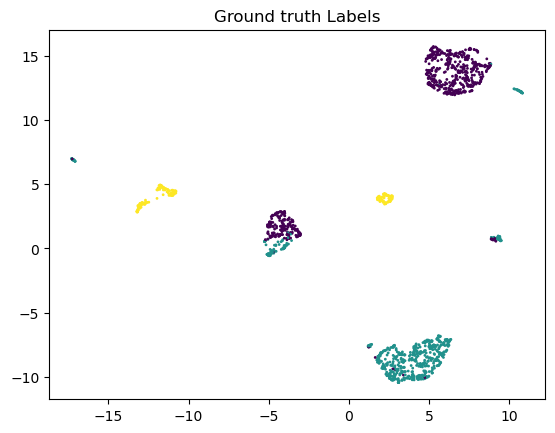

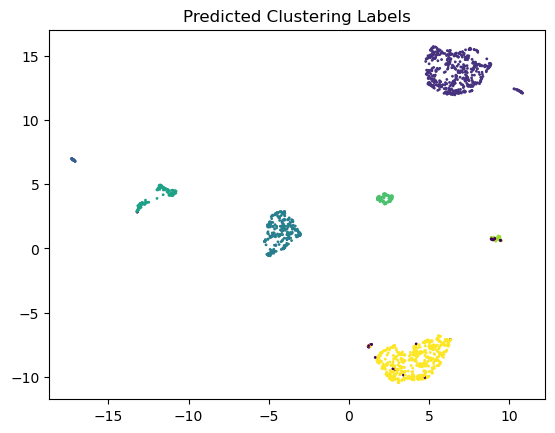

1562
Predicted Labels:  [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(-1)]
[[  0   0   0   0   0   0   0   0]
 [473   2 201   0   0   2   0  16]
 [ 29  25  77   0   0  39 483  17]
 [  0   0   0 122  75   0   0   1]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]]
Precision:  0.8987266916200927
Recall:  0.5431191371834518
F1 score 0.6770705377307715
Adjusted Rand Index:  0.5392368879682446
Normalized Mutual Info:  0.598384633999644


In [8]:
# evaluation

# remap feature vectors to 2D representation for plotting
plot_reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1)
coords = plot_reducer.fit_transform(embedding_features)
# plot ground truth
plt.title("Ground truth Labels")
plt.scatter(coords[:, 0], coords[:, 1], s=1, c=ground_truth_labels)
plt.show()
# plot predictions labels
plt.title("Predicted Clustering Labels")
plt.scatter(coords[:, 0], coords[:, 1], s=1, c=cluster_labels)
plt.show()

# calculate metrics
print(len(ground_truth_labels))
print("Predicted Labels: ", list(set(cluster_labels)))
print(confusion_matrix(ground_truth_labels, cluster_labels,labels=list(set(cluster_labels))))
print("Precision: ", pairwise_precision(cluster_labels, ground_truth_labels))
print("Recall: ", pairwise_recall(cluster_labels, ground_truth_labels))
print("F1 score", pairwise_f(cluster_labels, ground_truth_labels))
print("Adjusted Rand Index: ", adjusted_rand_score(ground_truth_labels, cluster_labels))
print("Normalized Mutual Info: ", normalized_mutual_info_score(ground_truth_labels, cluster_labels))

In [19]:
# simple demonstration of the PNN classifier
%load_ext autoreload
%autoreload 2
from ClassificationHeads import ProgressiveNeuralNetworkClassifier

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=0.01)

classifier = ProgressiveNeuralNetworkClassifier(23,10).to(device)
ground, predict = train_classifier(classifier, criterion, optimizer,embedding_features, ground_truth_labels)
print("accuracy: ", accuracy_score(ground_truths, predictions))
print("recall: ", recall_score(ground_truths, predictions, average="macro"))
print("f1 score: ", f1_score(ground_truths, predictions, average="macro"))
print(confusion_matrix(ground_truths, predictions))

classifier.expand_classifier(2)
weights_before = classifier.fc.weight.data.detach().clone()
ground, predict = train_classifier(classifier, criterion, optimizer,embedding_features, ground_truth_labels)
print("is same: ", weights_before == classifier.fc.weight.data)
print("accuracy: ", accuracy_score(ground_truths, predictions))
print("recall: ", recall_score(ground_truths, predictions, average="macro"))
print("f1 score: ", f1_score(ground_truths, predictions, average="macro"))
print(confusion_matrix(ground_truths, predictions))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Epoch [1/15] - Loss: 5.4526
Epoch [2/15] - Loss: 5.4483
Epoch [3/15] - Loss: 5.4654
Epoch [4/15] - Loss: 5.4314
Epoch [5/15] - Loss: 5.4997
Epoch [6/15] - Loss: 5.4427
Epoch [7/15] - Loss: 5.4901
Epoch [8/15] - Loss: 5.4949
Epoch [9/15] - Loss: 5.4290
Epoch [10/15] - Loss: 5.5038
Epoch [11/15] - Loss: 5.4482
Epoch [12/15] - Loss: 5.4384
Epoch [13/15] - Loss: 5.4608
Epoch [14/15] - Loss: 5.4451
Epoch [15/15] - Loss: 5.4761
accuracy:  0.9871959026888605
recall:  0.9902045966134745
f1 score:  0.990221275894083
[[685   9   0]
 [ 11 659   0]
 [  0   0 198]]
Epoch [1/15] - Loss: 5.5650
Epoch [2/15] - Loss: 5.5898
Epoch [3/15] - Loss: 5.5863
Epoch [4/15] - Loss: 5.5693
Epoch [5/15] - Loss: 5.5918
Epoch [6/15] - Loss: 5.5980
Epoch [7/15] - Loss: 5.5599
Epoch [8/15] - Loss: 5.5523
Epoch [9/15] - Loss: 5.5874
Epoch [10/15] - Loss: 5.5758
Epoch [11/15] - Loss: 5.5674
Epoch [12/15] - Loss: 5.5573
Epoch [13/15] 

# Task 2 building the continual learning metric tracker matrix

In [4]:
from label_remapper import LabelRemapper
from continual_experiment_manager import ContinualExperimentManager
from ClassificationHeads import ProgressiveNeuralNetworkClassifier

In [5]:
DATASET_ROOT = "./datasets"   
MAX_TWEETS_PER_USER = 20
TWEET_BATCH_SIZE = 32
UMAP_COMPONENTS = 15
EPOCHS = 15
LEARNING_RATE = 0.01
USE_INTERVENTION_OVERRIDE = True
GENERATOR = torch.Generator().manual_seed(42)

In [6]:
TASK_DEFINITIONS = [
    (Cresci17SetTypes.GENUINE_USER,       "GenuineUser"),
    (Cresci17SetTypes.FAKE_FOLLOWER,      "FakeFollower"),
    (Cresci17SetTypes.SOCIAL_SPAM_1,      "SocialSpam1"),
    (Cresci17SetTypes.TRADITIONAL_SPAM_1, "TradSpam1"),
]

task_splits = []
for subset_type, task_name in TASK_DEFINITIONS:
    dataset = Cresci17(root=DATASET_ROOT, subset_type=subset_type)
    train_split, test_split = random_split(dataset, [0.8, 0.2], generator=GENERATOR)
    native_label = subset_type.value
    task_splits.append((train_split, test_split, task_name, native_label))
    print(f"Loaded '{task_name}': {len(train_split)} train, {len(test_split)} test (native label={native_label})")

Loaded 'GenuineUser': 2779 train, 694 test (native label=1)


d:\Ulm\NLP AND NLM\Project\-Social-Media-Bot-Detection-with-Continuous-Learning\dataset_utils\Cresci17.py:80: DtypeWarning: Columns (0: favorite_count) have mixed types. Specify dtype option on import or set low_memory=False.
  self.tweet_data = pd.read_csv(tweet_data_path, encoding="latin-1", dtype={'id': str},


Loaded 'FakeFollower': 2681 train, 670 test (native label=2)
Loaded 'SocialSpam1': 793 train, 198 test (native label=3)
Loaded 'TradSpam1': 800 train, 200 test (native label=6)


In [7]:
def embed_split(split, task_name):
    loader = DataLoader(split, batch_size=None, shuffle=False)
    features = []
    labels = []
    print(f"  Embedding {len(split)} samples from '{task_name}'...")
    for i, (sample, label) in enumerate(loader):
        if i % 100 == 0:
            print(f"    {i}/{len(split)}")
        profile_vec = create_profile_vector(sample)
        tweet_vecs = create_tweet_vectors(
            sample, tokenizer=tokenizer, model=model,
            batch_size=TWEET_BATCH_SIZE, max_tweets=MAX_TWEETS_PER_USER, device=device
        )
        tweet_vec = torch.max(tweet_vecs, dim=0).values
        combined = torch.cat([profile_vec, tweet_vec], dim=0)
        features.append(combined.numpy())
        labels.append(int(label))
    return np.array(features), labels

In [ ]:
print("Embedding ALL tasks upfront to fit UMAP and Scaler on all classes...")

all_raw_features = []
all_labels = []

for train_split, _, task_name, native_label in task_splits:
    raw, lbls = embed_split(train_split, task_name)
    all_raw_features.append(raw)
    all_labels.extend(lbls)
    print(f"  Done embedding '{task_name}'")

all_raw_features = np.vstack(all_raw_features)
print(f"\nTotal samples for UMAP fitting: {all_raw_features.shape}")

print("Fitting RobustScaler...")
scaler = RobustScaler()
all_scaled = scaler.fit_transform(all_raw_features)

print(f"Fitting UMAP (n_components={UMAP_COMPONENTS})...")
umap_reducer = umap.UMAP(n_components=UMAP_COMPONENTS, random_state=42)
umap_reducer.fit(all_scaled)
print("UMAP fitted on all classes. Done!")

# now split back out task 0 embeddings for the main loop
# (since the main loop reuses umap_features_task0 for task 0)
task0_size = len(task_splits[0][0])  # number of training samples in task 0
task0_scaled = all_scaled[:task0_size]
umap_features_task0 = umap_reducer.transform(task0_scaled)
raw_features_task0 = all_raw_features[:task0_size]
labels_task0 = all_labels[:task0_size]

print(f"Task 0 UMAP shape: {umap_features_task0.shape}")

def transform_features(raw_features):
    scaled = scaler.transform(raw_features)
    return umap_reducer.transform(scaled)

Fitting UMAP and Scaler on Task 0 training data...
  Embedding 2779 samples from 'GenuineUser'...
    0/2779
    100/2779
    200/2779
    300/2779
    400/2779
    500/2779
    600/2779
    700/2779
    800/2779
    900/2779
    1000/2779
    1100/2779
    1200/2779
    1300/2779
    1400/2779
    1500/2779
    1600/2779
    1700/2779
    1800/2779
    1900/2779
    2000/2779
    2100/2779
    2200/2779
    2300/2779
    2400/2779
    2500/2779
    2600/2779
    2700/2779


c:\Users\Hamouda\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done. UMAP output shape: (2779, 15)


In [9]:
label_remapper = LabelRemapper()
experiment_manager = ContinualExperimentManager(
    num_tasks=len(task_splits),
    use_intervention_override=USE_INTERVENTION_OVERRIDE # this is task 3 for label mismatch
)

classifier = ProgressiveNeuralNetworkClassifier(
    in_features=UMAP_COMPONENTS,
    output_dim=1,
    dropout_p=0.1
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
test_splits_cache = []

In [10]:
# Debug: check if weight freezing is actually working
print("Testing PNN weight freezing...")
print(f"Classifier num_classes: {classifier.num_classes}")
print(f"Frozen layers before expand: {classifier.frozenLayers}")

# expand and check
classifier.expand_classifier(num_to_add=1)
print(f"Frozen layers after expand: {classifier.frozenLayers}")
print(f"Classifier num_classes after expand: {classifier.num_classes}")

# check the hook is registered
print(f"Weight hooks: {classifier.fc.weight._backward_hooks}")

Testing PNN weight freezing...
Classifier num_classes: 1
Frozen layers before expand: []
Frozen layers after expand: [0]
Classifier num_classes after expand: 2
Weight hooks: OrderedDict({2: <bound method ProgressiveNeuralNetworkClassifier._weight_freeze_hook of ProgressiveNeuralNetworkClassifier(
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=15, out_features=2, bias=True)
)>})


In [23]:
for task_idx, (train_split, test_split, task_name, native_label) in enumerate(task_splits):
    print(f"\n{'='*60}")
    print(f"STEP {task_idx}: '{task_name}' (native label={native_label})")
    print(f"{'='*60}")

    # 1. Embed training data
    if task_idx == 0:
        umap_train = umap_features_task0
        native_train_labels = labels_task0
    else:
        raw_train, native_train_labels = embed_split(train_split, task_name)
        umap_train = transform_features(raw_train)

    # 2. Run HDBSCAN
    print(f"Running HDBSCAN on {len(umap_train)} samples...")
    clusterer = hdbscan.HDBSCAN(min_cluster_size=10, prediction_data=True)
    cluster_labels = clusterer.fit_predict(umap_train)

    # 3. Expand classifier if needed
    if task_idx == 0:
        print("Task 0: no expansion needed.")
    else:
        experiment_manager.check_clusterer_and_expand(
            clusterer_labels=cluster_labels,
            ground_truth_labels=native_train_labels,
            classifier=classifier
        )

    # 4. Remap labels
    label_remapper.register(native_label)
    remapped_train_labels = label_remapper.convert(native_train_labels)
    print(f"Label remapper: {label_remapper}")

    # 5. Re-create optimizer after expansion
    optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)

    # 6. Train
    print(f"Training for {EPOCHS} epochs...")
    train_classifier(classifier, criterion, optimizer, umap_train, remapped_train_labels, epochs=EPOCHS, device=device)

    # 7. Embed and cache test split
    raw_test, native_test_labels = embed_split(test_split, task_name)
    umap_test = transform_features(raw_test)
    remapped_test_labels = label_remapper.convert(native_test_labels)
    test_splits_cache.append((umap_test, remapped_test_labels, task_name))

    # 8. Evaluate on all past test splits
    print(f"Evaluating on all {len(test_splits_cache)} test split(s)...")
    for j, (cached_features, cached_labels, cached_name) in enumerate(test_splits_cache):
        ground_truths, predictions = test_classifier(classifier, cached_features, cached_labels, device=device)
        acc = accuracy_score(ground_truths, predictions)
        f1  = f1_score(ground_truths, predictions, average="macro", zero_division=0)
        print(f"  Task {j} ('{cached_name}'): acc={acc:.4f}, f1={f1:.4f}")
        experiment_manager.record_accuracy(task_index=j, accuracy=acc)

    # 9. Advance
    experiment_manager.advance_to_next_task()

experiment_manager.summary()


STEP 0: 'GenuineUser' (native label=1)
Running HDBSCAN on 2779 samples...
Task 0: no expansion needed.
Label remapper: LabelRemapper({1: 0})
Training for 15 epochs...
Epoch [1/15] - Loss: 0.0000
Epoch [2/15] - Loss: 0.0000
Epoch [3/15] - Loss: 0.0000
Epoch [4/15] - Loss: 0.0000
Epoch [5/15] - Loss: 0.0000
Epoch [6/15] - Loss: 0.0000
Epoch [7/15] - Loss: 0.0000
Epoch [8/15] - Loss: 0.0000
Epoch [9/15] - Loss: 0.0000
Epoch [10/15] - Loss: 0.0000
Epoch [11/15] - Loss: 0.0000
Epoch [12/15] - Loss: 0.0000
Epoch [13/15] - Loss: 0.0000
Epoch [14/15] - Loss: 0.0000
Epoch [15/15] - Loss: 0.0000
  Embedding 694 samples from 'GenuineUser'...
    0/694
    100/694
    200/694
    300/694
    400/694
    500/694
    600/694
Evaluating on all 1 test split(s)...
  Task 0 ('GenuineUser'): acc=1.0000, f1=1.0000

--- Step 0 complete ---
    Avg Accuracy (this step): 1.0000
    Forgetting Measure:       0.0000
    Row scores: ['1.000']

=== Now starting Step 1 ===


STEP 1: 'FakeFollower' (native label=